In [2]:
# Cell 1: Setup, Config, and Data Loading
from pathlib import Path
import sys
import yaml
import numpy as np
import pandas as pd
from importlib import reload

# Target zone for local interpretability analysis
TARGET_ZONE = "FR"

# Resolve project root from notebooks/
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# Pipeline imports
from src.data_ingestion import load_and_merge_zone
import src.features as features_module
features_module = reload(features_module)
build_features = features_module.build_features
from src.preprocessing import chronological_train_val_test_split, scale_data
from src.constants import TARGET_COL

# Load config and tuned-parameter artifact
with open(ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)

artifact_path = ROOT / "best_hyperparameters.yaml"
if artifact_path.exists():
    with open(artifact_path, "r") as f:
        best_hyperparams = yaml.safe_load(f) or {}
else:
    best_hyperparams = {}
    print("Warning: best_hyperparameters.yaml not found. Falling back to config defaults.")

# Load raw zone data (resolve relative config path from project root)
raw_dir_cfg = config.get("data", {}).get("raw_dir", "data/raw/auhack_legacy/")
raw_dir_path = Path(raw_dir_cfg)
if not raw_dir_path.is_absolute():
    raw_dir_path = (ROOT / raw_dir_path).resolve()

# Extract target zones and flow-only zones from global config
target_zones = config["data"]["target_zones"]
flow_only_zones = config["data"].get("flow_only_zones", [])
all_zones = list(dict.fromkeys(target_zones + flow_only_zones))

# Build the God-Matrix: load all relevant zones into raw_data_dict for build_features
# Flow-only zones may not have spot/load/generation files in this dataset, so skip missing ones.
raw_data_dict = {}
for z in all_zones:
    try:
        raw_data_dict[z] = load_and_merge_zone(z, str(raw_dir_path))
    except FileNotFoundError as exc:
        print(f"Warning: skipping zone {z} during preload: {exc}")

if TARGET_ZONE not in raw_data_dict:
    raise ValueError(f"Target zone {TARGET_ZONE} could not be loaded from {raw_dir_path}")

# Use build_features to engineer the feature matrix (centralized pipeline)
df, active_features = build_features(raw_data_dict, TARGET_ZONE, lag_actual_flows=True)

# Chronological split (same structure as training pipeline)
train_df, val_df, test_df = chronological_train_val_test_split(df, val_ratio=0.15, test_ratio=0.15)

X_train = train_df[active_features]
y_train = train_df[TARGET_COL]
X_val = val_df[active_features]
y_val = val_df[TARGET_COL]

# Scale only if needed by the pipeline path you are inspecting
USE_SCALED_FEATURES = True
if USE_SCALED_FEATURES:
    X_train_model, X_val_model, _, x_scaler = scale_data(X_train, X_val, test_df[active_features])
else:
    X_train_model, X_val_model = X_train.copy(), X_val.copy()
    x_scaler = None

print(f"Target zone: {TARGET_ZONE}")
print(f"Raw directory: {raw_dir_path}")
print(f"Loaded zones: {sorted(raw_data_dict.keys())}")
print(f"X_train shape: {X_train_model.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val_model.shape} | y_val shape: {y_val.shape}")

[INGESTION] AT loaded with columns: ['Spot_Price', 'Total_Load', 'BIOMASS', 'FOSSIL-GAS', 'GEOTHERMAL', 'HARD-COAL', 'HYDRO-PUMPED-STORAGE', 'HYDRO-ROR', 'HYDRO-WATER-RESERVOIR', 'OIL']...
[INGESTION] BE loaded with columns: ['Spot_Price', 'Total_Load', 'BIOMASS', 'ENERGY-STORAGE', 'FOSSIL-GAS', 'HYDRO-PUMPED-STORAGE', 'HYDRO-ROR', 'NUCLEAR', 'OIL', 'OTHER']...
[INGESTION] CH loaded with columns: ['Spot_Price', 'Total_Load', 'HYDRO-PUMPED-STORAGE', 'HYDRO-ROR', 'HYDRO-WATER-RESERVOIR', 'NUCLEAR', 'SOLAR', 'WIND-ONSHORE', 'temperature_2m', 'wind_speed_10m']...
[INGESTION] CZ loaded with columns: ['Spot_Price', 'Total_Load', 'BIOMASS', 'COAL-DERVIED GAS', 'FOSSIL-GAS', 'HARD-COAL', 'HYDRO-PUMPED-STORAGE', 'HYDRO-ROR', 'HYDRO-WATER-RESERVOIR', 'LIGNITE']...
[INGESTION] DE loaded with columns: ['Spot_Price', 'Total_Load', 'BIOMASS', 'COAL-DERVIED GAS', 'FOSSIL-GAS', 'GEOTHERMAL', 'HARD-COAL', 'HYDRO-PUMPED-STORAGE', 'HYDRO-ROR', 'HYDRO-WATER-RESERVOIR']...
[INGESTION] DK1 loaded with colum

[INFO] Active features breakdown for FR:
[INFO]   - Raw exogenous (weather/load): 25 cols
[INFO]   - Deterministic (cyclical): 6 cols
[INFO]   - Autoregressive (lags/rolling): 66 cols
[INFO] Total active features: 97


Target zone: FR
Raw directory: C:\Users\mathi\Code\incommodities-case-crunch-2026\data\raw\auhack_legacy
Loaded zones: ['AT', 'BE', 'CH', 'CZ', 'DE', 'DK1', 'FR', 'NL', 'PL']
X_train shape: (12282, 97) | y_train shape: (12282,)
X_val shape: (2631, 97) | y_val shape: (2631,)


In [3]:
# Cell 2: The Global Feature Roster
feature_names = X_train.columns.tolist()

print(f"Total number of engineered features: {len(feature_names)}")
print("\nFull Feature List:")
for i, feat in enumerate(feature_names, start=1):
    print(f"{i:>2}. {feat}")

Total number of engineered features: 97

Full Feature List:
 1. Total_Load
 2. BIOMASS
 3. ENERGY-STORAGE
 4. FOSSIL-GAS
 5. HARD-COAL
 6. HYDRO-PUMPED-STORAGE
 7. HYDRO-ROR
 8. HYDRO-WATER-RESERVOIR
 9. NUCLEAR
10. OIL
11. SOLAR
12. WASTE
13. WIND-OFFSHORE
14. WIND-ONSHORE
15. temperature_2m
16. wind_speed_10m
17. wind_speed_100m
18. relative_humidity_2m
19. cloud_cover
20. wind_direction_10m
21. wind_direction_100m
22. precipitation
23. Renewables
24. Baseload
25. Dispatchable
26. Hour_Sin
27. Hour_Cos
28. DayOfWeek_Sin
29. DayOfWeek_Cos
30. Month_Sin
31. Month_Cos
32. Spot_Price_Filtered_lag_24
33. Spot_Price_Filtered_lag_48
34. Spot_Price_Filtered_lag_168
35. Residual_Load_lag_24
36. Residual_Load_lag_48
37. Residual_Load_lag_168
38. AT_Spot_Price_Filtered_lag_24
39. AT_Spot_Price_Filtered_lag_48
40. AT_Spot_Price_Filtered_lag_168
41. AT_Residual_Load_lag_24
42. AT_Residual_Load_lag_48
43. AT_Residual_Load_lag_168
44. BE_Spot_Price_Filtered_lag_24
45. BE_Spot_Price_Filtered_lag_48


LEAR params for FR: calibration_window=364, alpha=9.833240817856504
Surviving features (coef != 0): 4
Killed features (coef == 0): 93


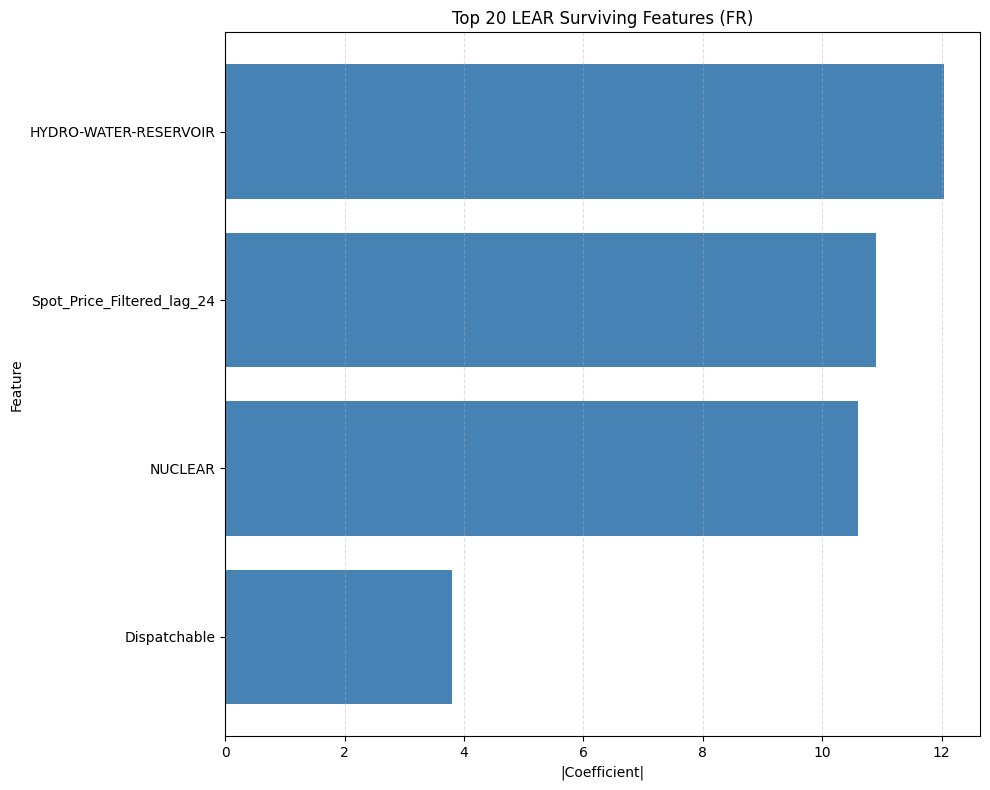

In [4]:
# Cell 3: LEAR (Lasso) Autopsy & Shrinkage Analysis
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

lear_zone_params = best_hyperparams.get("LEAR", {}).get(TARGET_ZONE, {})
default_cw = config.get("model_settings", {}).get("lear", {}).get("calibration_window_days", 182)
default_alpha = config.get("model_settings", {}).get("lear", {}).get("alpha", 0.001)

calibration_window = int(lear_zone_params.get("calibration_window", default_cw))
alpha = float(lear_zone_params.get("alpha", default_alpha))

window_start = X_train_model.index.max() - pd.Timedelta(days=calibration_window)
X_train_recent = X_train_model.loc[X_train_model.index >= window_start]
y_train_recent = y_train.loc[X_train_recent.index]

if len(X_train_recent) < 50:
    X_train_recent = X_train_model.copy()
    y_train_recent = y_train.copy()

# Lasso does not accept NaNs; impute using train-window medians only (no lookahead).
X_train_recent = X_train_recent.replace([np.inf, -np.inf], np.nan)
feature_medians = X_train_recent.median(numeric_only=True)
X_train_recent = X_train_recent.fillna(feature_medians).fillna(0.0)

y_mask = y_train_recent.notna()
X_train_recent = X_train_recent.loc[y_mask]
y_train_recent = y_train_recent.loc[y_mask]

lear_model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
lear_model.fit(X_train_recent, y_train_recent)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": lear_model.coef_
})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

survivors = coef_df[coef_df["coef"] != 0].copy()
killed = coef_df[coef_df["coef"] == 0].copy()

print(f"LEAR params for {TARGET_ZONE}: calibration_window={calibration_window}, alpha={alpha}")
print(f"Surviving features (coef != 0): {len(survivors)}")
print(f"Killed features (coef == 0): {len(killed)}")

top20 = survivors.head(20).sort_values("abs_coef", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top20["feature"], top20["abs_coef"], color="steelblue")
plt.title(f"Top 20 LEAR Surviving Features ({TARGET_ZONE})")
plt.xlabel("|Coefficient|")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005650 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22381
[LightGBM] [Info] Number of data points in the train set: 12282, number of used features: 97
[LightGBM] [Info] Start training from score 62.367457


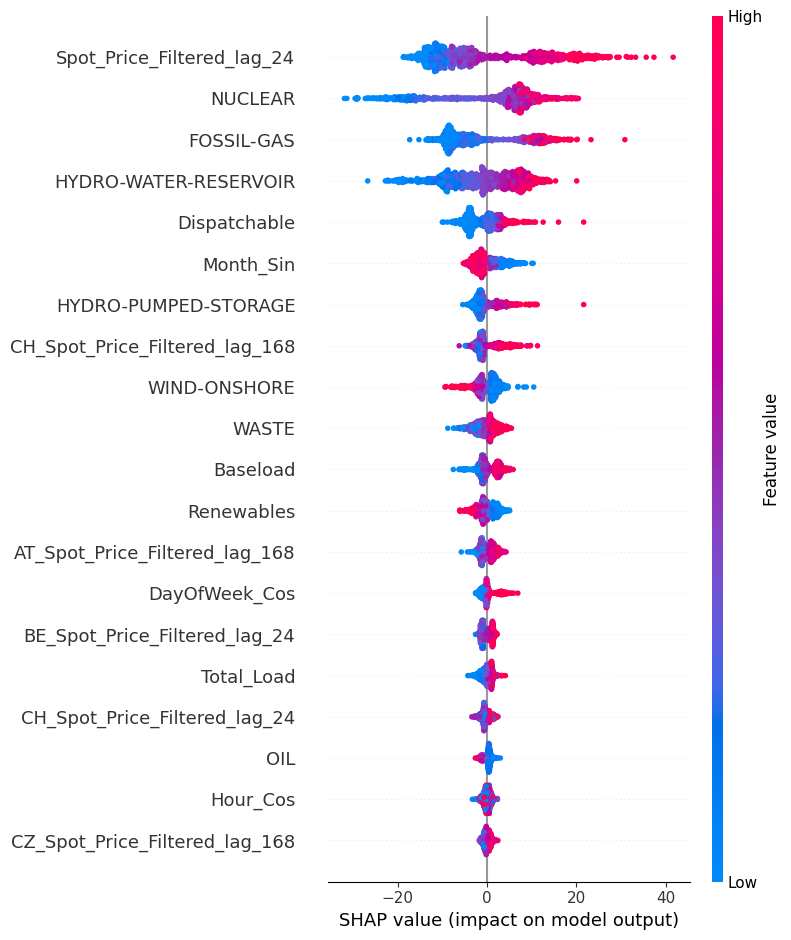

In [5]:
# Cell 4: Non-Linear Tree Analysis (LightGBM & SHAP)
import lightgbm as lgb
import shap

lgb_default = config.get("model_settings", {}).get("trees", {}).get("lgb", {}).copy()
lgb_zone_params = best_hyperparams.get("LightGBM", {}).get(TARGET_ZONE, lgb_default).copy()

# Strict integer casting for critical parameters
for p in ["num_leaves", "n_estimators", "max_depth"]:
    if p in lgb_zone_params and lgb_zone_params[p] is not None:
        lgb_zone_params[p] = int(lgb_zone_params[p])

fit_params = {}
if "early_stopping_rounds" in lgb_zone_params:
    es = int(lgb_zone_params.pop("early_stopping_rounds"))
    fit_params["callbacks"] = [lgb.early_stopping(stopping_rounds=es, verbose=False)]

lgb_model = lgb.LGBMRegressor(**lgb_zone_params)
lgb_model.fit(X_train_model, y_train, eval_set=[(X_val_model, y_val)], **fit_params)

background = X_train_model.sample(n=min(1000, len(X_train_model)), random_state=42)
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(background)

shap.summary_plot(shap_values, background)